In [37]:
import yfinance as yf
import pandas as pd

In [38]:
obj = yf.Ticker('TATAELXSI.NS')

In [39]:
data= obj.history(period='5y')

In [40]:
data = pd.DataFrame(data)

In [41]:
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-08-29 00:00:00+05:30,620.124728,620.220124,597.367386,599.991394,810449,0.0,0.0
2019-08-30 00:00:00+05:30,603.999025,606.241336,592.930504,603.283386,569664,0.0,0.0
2019-09-03 00:00:00+05:30,603.044838,614.495056,596.460939,598.703308,607064,0.0,0.0
2019-09-04 00:00:00+05:30,602.424598,605.907396,578.236035,582.291321,1026040,0.0,0.0
2019-09-05 00:00:00+05:30,583.245438,593.455226,583.245438,590.354126,570377,0.0,0.0
...,...,...,...,...,...,...,...
2024-08-23 00:00:00+05:30,6975.000000,7139.000000,6930.100098,7088.149902,197126,0.0,0.0
2024-08-26 00:00:00+05:30,7149.000000,7940.000000,7103.000000,7683.049805,1291665,0.0,0.0
2024-08-27 00:00:00+05:30,7800.000000,9080.000000,7750.000000,8971.400391,5503022,0.0,0.0


In [42]:
close_data=data.Close

In [43]:
close_data.shape

(1236,)

<function matplotlib.pyplot.show(close=None, block=None)>

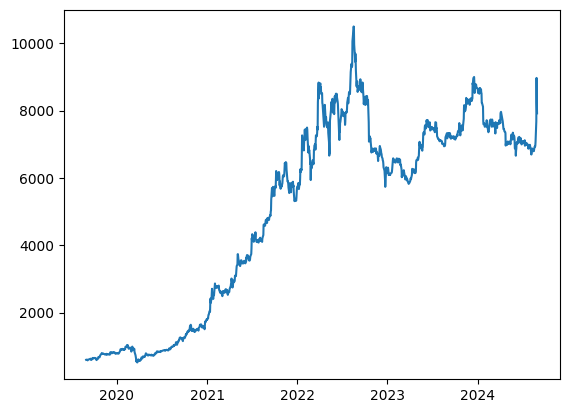

In [44]:
import matplotlib.pyplot as plt
plt.plot(close_data)
plt.show

In [45]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [46]:
import numpy as np
close_data = np.array(close_data)

In [47]:
close_data = scaler.fit_transform(close_data.reshape(-1, 1))

In [48]:
close_data

array([[0.00806948],
       [0.00839934],
       [0.00794041],
       ...,
       [0.84688983],
       [0.77235056],
       [0.74178438]])

In [49]:
tr_size = int(0.65*len(close_data))
te_size = len(close_data) - tr_size

In [50]:
def create_dataset(data, look_period):
    dataX, dataY = [], []
    for i in range(data.shape[0] - look_period):
        dataX.append(data[i:i+look_period, 0])
        dataY.append(data[i+look_period, 0])
    return np.array(dataX), np.array(dataY)

In [51]:
x_train, y_train = create_dataset(close_data[:tr_size], 100)
x_test, y_test = create_dataset(close_data[tr_size:], 100)

In [52]:
##Creating the stacked lSTM model

In [53]:
import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense

In [54]:
model = Sequential()

In [55]:
model.add(LSTM(50, return_sequences= True, input_shape= (100, 1)))
model.add(LSTM(50, return_sequences= True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer = 'adam', metrics = ['accuracy'])

C:\Users\Yash Garg\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [56]:
model.fit(x_train, y_train, epochs = 5, validation_data=(x_test, y_test), batch_size = 1, verbose = 1)

Epoch 1/5
703/703 ━━━━━━━━━━━━━━━━━━━━ 64s 85ms/step - accuracy: 0.0028 - loss: 0.0140 - val_accuracy: 0.0000e+00 - val_loss: 0.0020
Epoch 2/5
703/703 ━━━━━━━━━━━━━━━━━━━━ 58s 83ms/step - accuracy: 0.0036 - loss: 0.0029 - val_accuracy: 0.0000e+00 - val_loss: 0.0014
Epoch 3/5
703/703 ━━━━━━━━━━━━━━━━━━━━ 59s 84ms/step - accuracy: 0.0036 - loss: 0.0017 - val_accuracy: 0.0000e+00 - val_loss: 6.5009e-04
Epoch 4/5
703/703 ━━━━━━━━━━━━━━━━━━━━ 59s 84ms/step - accuracy: 7.6108e-04 - loss: 0.0018 - val_accuracy: 0.0000e+00 - val_loss: 0.0018
Epoch 5/5
703/703 ━━━━━━━━━━━━━━━━━━━━ 59s 84ms/step - accuracy: 0.0058 - loss: 0.0011 - val_accuracy: 0.0000e+00 - val_loss: 3.8767e-04


In [57]:
train_predict = model.predict(x_train)
test_predict = model.predict(x_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [58]:
test_predict = scaler.inverse_transform(test_predict)
train_predict = scaler.inverse_transform(train_predict)

In [59]:
y_test = scaler.inverse_transform([y_test])
y_test

array([[6144.4140625 , 6162.34716797, 6181.65625   , 6464.01855469,
        6528.28271484, 6527.93896484, 6562.52832031, 6604.63427734,
        6544.64404297, 6661.62744141, 6870.58691406, 6998.23193359,
        7073.40380859, 6955.73291016, 6909.54882813, 6992.18896484,
        6975.92529297, 6874.17333984, 6905.37207031, 6810.69433594,
        6901.14648438, 6910.38378906, 7134.96630859, 7337.48925781,
        7364.85595703, 7293.171875  , 7292.72998047, 7501.98339844,
        7562.36669922, 7564.52832031, 7472.50390625, 7559.51660156,
        7708.48535156, 7681.90527344, 7722.09570312, 7715.70800781,
        7615.38037109, 7651.39404297, 7507.58447266, 7549.88769531,
        7635.57373047, 7655.52148438, 7593.22851562, 7409.71777344,
        7435.26855469, 7473.34765625, 7512.91162109, 7515.23876953,
        7473.44628906, 7441.25976562, 7480.13085938, 7462.60205078,
        7468.84130859, 7414.96630859, 7381.1953125 , 7359.50683594,
        7494.98632812, 7656.11572266, 7644.97412

In [60]:
test_predict.shape, y_test.shape

((333, 1), (1, 333))

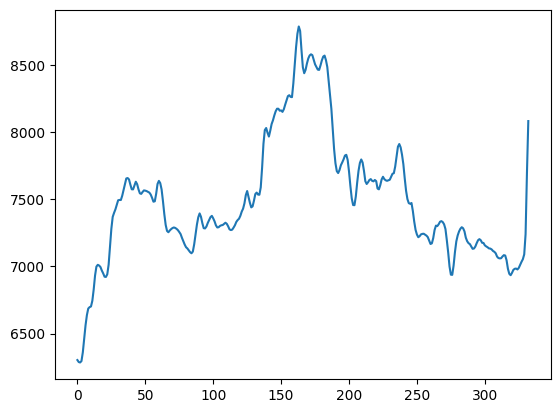

In [61]:
plt.plot(test_predict)

In [62]:
temp = [[i] for i in y_test[0]]

In [63]:
temp = np.array(temp)
temp.shape

(333, 1)

In [64]:
y_test = temp

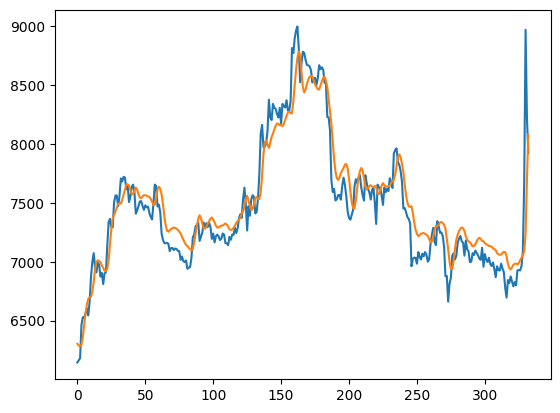

In [65]:
plt.plot(y_test)
plt.plot(test_predict)

In [66]:
y_train = scaler.inverse_transform(y_train.reshape(y_train.shape[0], 1))

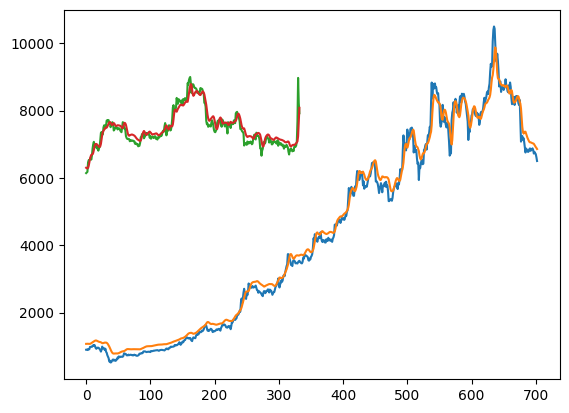

In [67]:
plt.plot(y_train)
plt.plot(train_predict)
plt.plot(y_test)
plt.plot(test_predict)

In [68]:
y_train = [i[0] for i in y_train]

In [69]:
train_predict = [i[0] for i in train_predict]
y_test = [i[0] for i in y_test]
test_predict = [i[0] for i in test_predict]

In [70]:
given = y_train + y_test

In [71]:
got = train_predict + test_predict

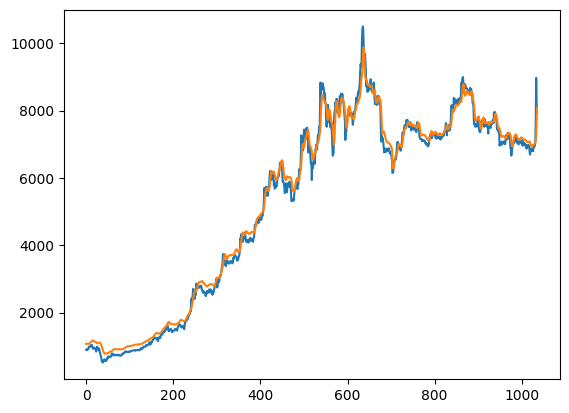

In [72]:
plt.plot(given)
plt.plot(got)